In [1]:
from pathlib import Path
import numpy as np
from astropy import stats
from astropy.time import Time
from astropy.table import Table, MaskedColumn
from kpf_etc.etc import kpf_photon_noise_estimate

import matplotlib.pyplot as plt

data_file = 'data/Feb2026_anonymized.csv'
t = Table.read(data_file, format='ascii.csv')

In [2]:
# KPFERA 1.0 is before SM1
SM1start = Time('2024-02-03')
SM1end = Time('2024-02-23')
# KPFERA 2.0 is between SM1 and SM2
SM2start = Time('2024-10-31')
SM2end = Time('2024-11-20')
# KPFERA 2.5/2.6 is between SM2 and SM3
SM3start = Time('2025-03-28')
SM3end = Time('2025-04-23')
# KPFERA 3.0 is between SM3 and SM4
SM4start = Time('2025-08-29')
SM4end = Time('2025-10-27')
# KPFERA 4.0 is after SM4

In [3]:
def Nmasked(t):
    mask_count = int(np.sum(np.array(t['TOTCORR'].mask, dtype=int)))
    print(f"{mask_count} masked out of {len(t)}")

In [4]:
Nmasked(t)

2004 masked out of 12058


In [5]:
# Mask out negative exposure meter flux
t['TOTCORR'].mask = t['TOTCORR'].mask | (t['TOTCORR_SUM'] <= 0).data
Nmasked(t)

3651 masked out of 12058


In [6]:
# Mask out exposure meter data from before reformatter realignment
t['TOTCORR'].mask = t['TOTCORR'].mask | (t['MJD-OBS'] < SM1end.mjd).data
Nmasked(t)

4709 masked out of 12058


In [7]:
t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'TOTCORR_1'] / t['EXPTIME']), name='EMZP_1'))
t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'TOTCORR_2'] / t['EXPTIME']), name='EMZP_2'))
t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'TOTCORR_3'] / t['EXPTIME']), name='EMZP_3'))
t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'TOTCORR_4'] / t['EXPTIME']), name='EMZP_4'))
t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'TOTCORR_SUM'] / t['EXPTIME']), name='EMZP_SUM'))

/var/folders/3m/rvt2qsdx3nv0cv6m5rvbbgzc0000gp/T/ipykernel_6756/2451825147.py:1: RuntimeWarning: divide by zero encountered in log10
  t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'TOTCORR_1'] / t['EXPTIME']), name='EMZP_1'))
/var/folders/3m/rvt2qsdx3nv0cv6m5rvbbgzc0000gp/T/ipykernel_6756/2451825147.py:1: RuntimeWarning: invalid value encountered in log10
  t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'TOTCORR_1'] / t['EXPTIME']), name='EMZP_1'))
/var/folders/3m/rvt2qsdx3nv0cv6m5rvbbgzc0000gp/T/ipykernel_6756/2451825147.py:2: RuntimeWarning: divide by zero encountered in log10
  t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'TOTCORR_2'] / t['EXPTIME']), name='EMZP_2'))
/var/folders/3m/rvt2qsdx3nv0cv6m5rvbbgzc0000gp/T/ipykernel_6756/2451825147.py:2: RuntimeWarning: invalid value encountered in log10
  t.add_column(MaskedColumn(t['GAIAMAG'] + 2.5*np.log10(t[f'TOTCORR_2'] / t['EXPTIME']), name='EMZP_2'))
/var/folders/3m/rvt2qsdx3nv0cv6m5rvbbgzc0000gp/T/i

In [8]:
def calculate_ExpMeter_zero_point(t, EMbin=1, percentile=95, plot=False):
    mask = t['TOTCORR'].mask
    EMZP = float(np.percentile(t[f'EMZP_{EMbin}'][~mask], percentile))
    # print(f"Exposure Meter Zero Point = {EMZP:.2f}")

    if plot:
        plt.figure(figsize=(10,3))
        plt.title(f'Exposure Meter Zero Point (bin {EMbin}) = {EMZP:.2f}')
        plt.hist(t[f'EMZP_{EMbin}'][~mask], bins=100, density=True, label='Zero Points')
        plt.ylabel(f'Density (N={len(t[~mask])})')
        plt.axvline(EMZP, color='k', alpha=0.5, label='Nominal Zero Point')
        plt.grid()
        plt.legend(loc='best')
        plt.xlim(12,24)
        plt.xlabel('Zero Point (mag)')
        plt.show()

    return EMZP

/Users/jwalawender/miniforge3/envs/py313/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  arr.partition(


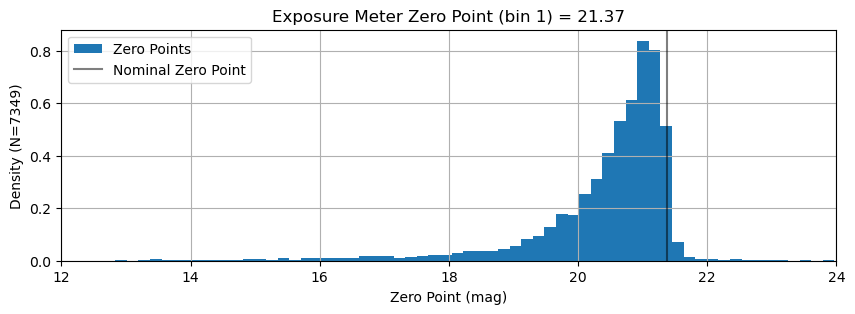

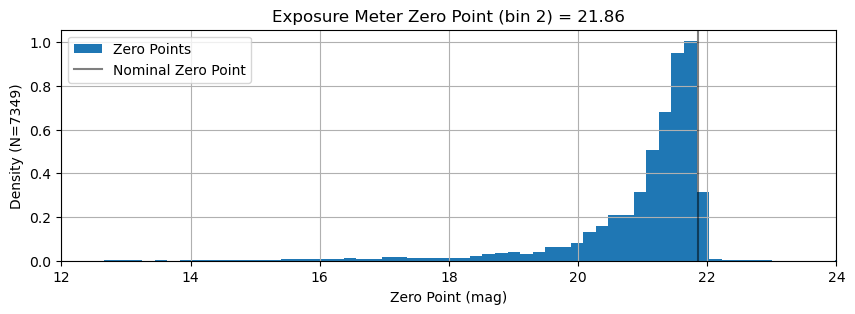

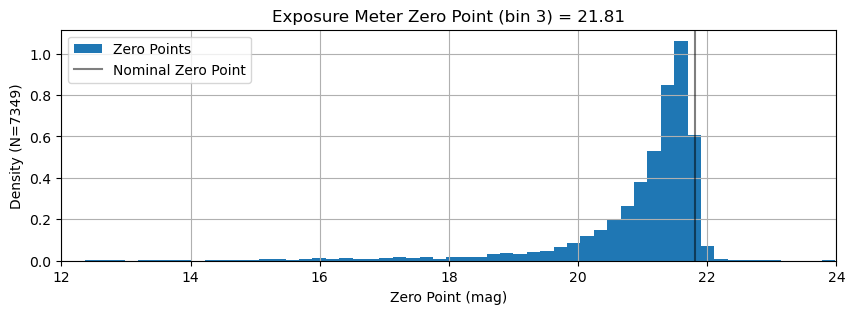

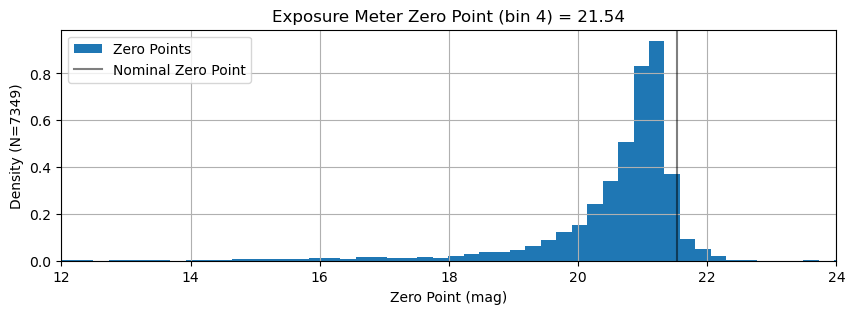

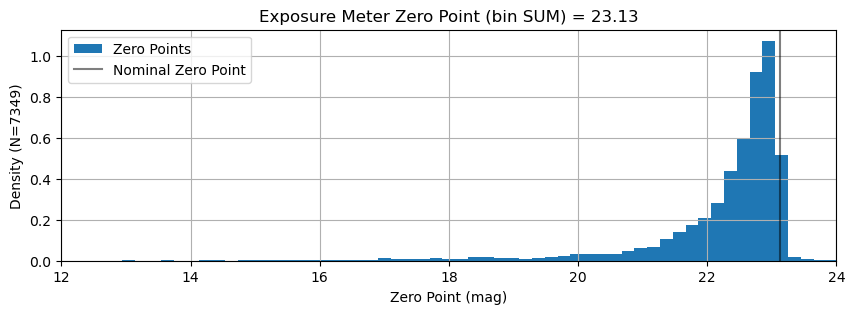

In [9]:
EMZeroPoint = {}
for EMbin in [1, 2, 3, 4, 'SUM']:
    EMZeroPoint[EMbin] = calculate_ExpMeter_zero_point(t, EMbin=EMbin, percentile=95, plot=True)

In [10]:
EMZeroPoint

{1: 21.372837780991826,
 2: 21.86128528452142,
 3: 21.813791696161033,
 4: 21.53655457132694,
 'SUM': 23.12766392123874}

## Check for Evolution Over Time

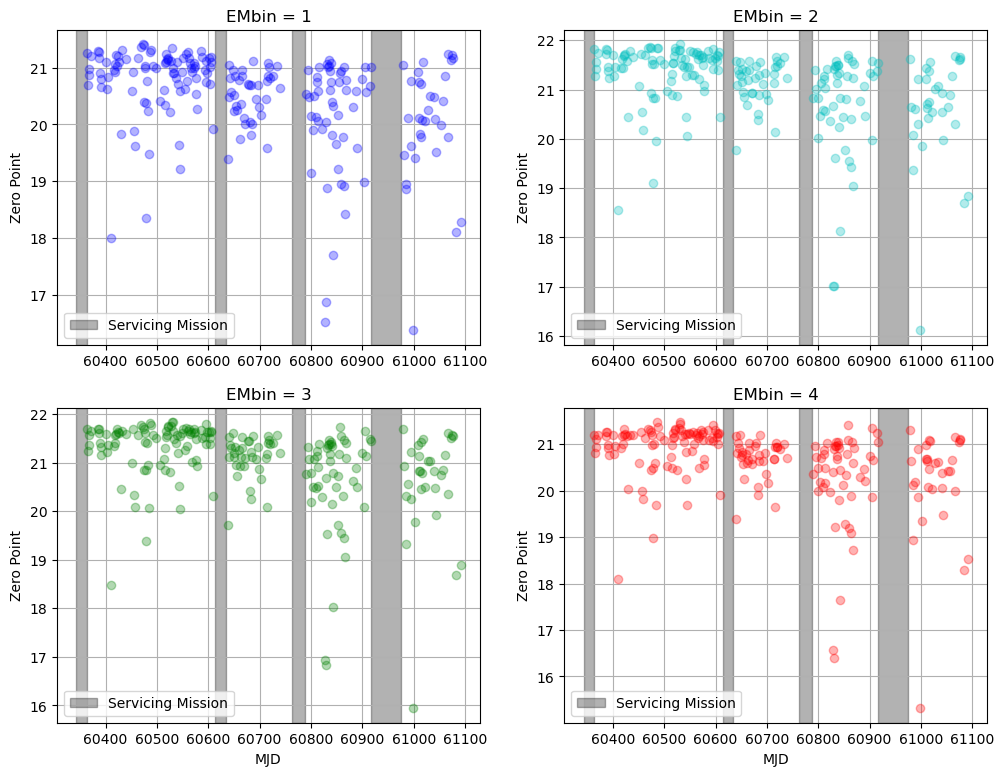

In [12]:
mask = t['TOTCORR'].mask
mjd = np.array([int(d) for d in t['MJD-OBS']])

plt.figure(figsize=(12,9))

for EMbin in [1, 2, 3, 4]:
    plt.subplot(2,2,EMbin)
    color = ['b', 'c', 'g', 'r'][EMbin-1]
    plt.title(f"EMbin = {EMbin}")
    for j,day in enumerate(set(mjd)):
        wday = (mjd == day) & ~mask
        if np.sum(np.array(wday, dtype=int)) > 5:
            zp = np.median(t[f'EMZP_{EMbin}'][wday])
            plt.plot(day, zp, f'{color}o', alpha=0.3)
    plt.axvspan(SM1start.mjd, SM1end.mjd, color='k', alpha=0.3, label='Servicing Mission')
    plt.axvspan(SM2start.mjd, SM2end.mjd, color='k', alpha=0.3)
    plt.axvspan(SM3start.mjd, SM3end.mjd, color='k', alpha=0.3)
    plt.axvspan(SM4start.mjd, SM4end.mjd, color='k', alpha=0.3)
    plt.ylabel(f'Zero Point')
    plt.legend(loc='best')
    # plt.gca().set_xticklabels([])
    if EMbin in [3, 4]:
        plt.xlabel('MJD')
    plt.grid()

plt.show()